In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
classification_results = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768803008.229797/ensemble_classification_predictions.csv")
classification_results.columns

Index(['verified_pattern', 'file', 'threshold_class',
       'without_threshold_class', 'second_level_model_class_lr',
       'second_level_model_class_rr'],
      dtype='object')

In [4]:
y_true = classification_results['verified_pattern']
y_pred = classification_results['second_level_model_class_lr']

With thresholding applied [precision]: 0.4932
Without thresholding [precision]: 0.4757
Second Level Model LR [precision]: 0.5057
Second Level Model RR [precision]: 0.4838

With thresholding applied [f1]: 0.3627
Without thresholding [f1]: 0.4707
Second Level Model LR [f1]: 0.5043
Second Level Model RR [f1]: 0.4800
With thresholding applied [recall]: 0.3820
Without thresholding [recall]: 0.4757
Second Level Model LR [recall]: 0.5094
Second Level Model RR [recall]: 0.4831

Classification Report for threshold_class:
                                                           precision    recall  f1-score   support

                                         Classical Models       0.70      0.49      0.57        47
                                   LLM Results Evaluation       0.50      0.08      0.13        13
                LLM based Multimodal Generative Prompting       0.75      0.35      0.47        26
                                Model Abstraction Pattern       0.60      0.19      0

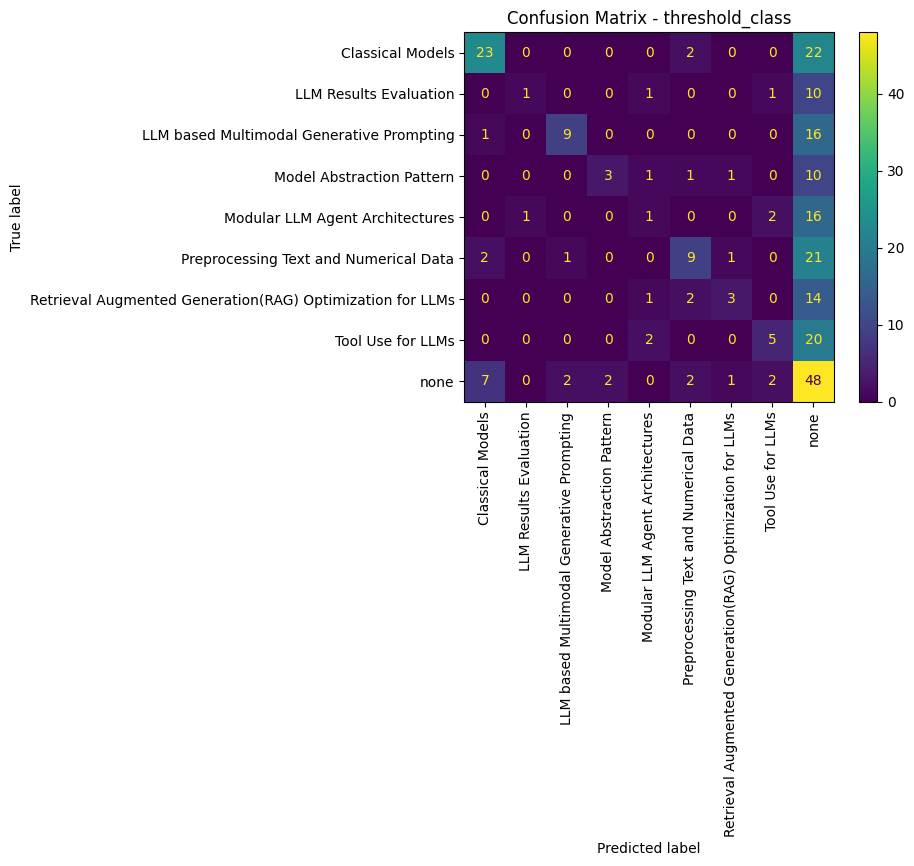


Classification Report for without_threshold_class:
                                                           precision    recall  f1-score   support

                                         Classical Models       0.61      0.66      0.63        47
                                   LLM Results Evaluation       0.60      0.23      0.33        13
                LLM based Multimodal Generative Prompting       0.53      0.62      0.57        26
                                Model Abstraction Pattern       0.40      0.38      0.39        16
                          Modular LLM Agent Architectures       0.42      0.40      0.41        20
                    Preprocessing Text and Numerical Data       0.39      0.44      0.42        34
Retrieval Augmented Generation(RAG) Optimization for LLMs       0.41      0.35      0.38        20
                                        Tool Use for LLMs       0.36      0.33      0.35        27
                                                     non

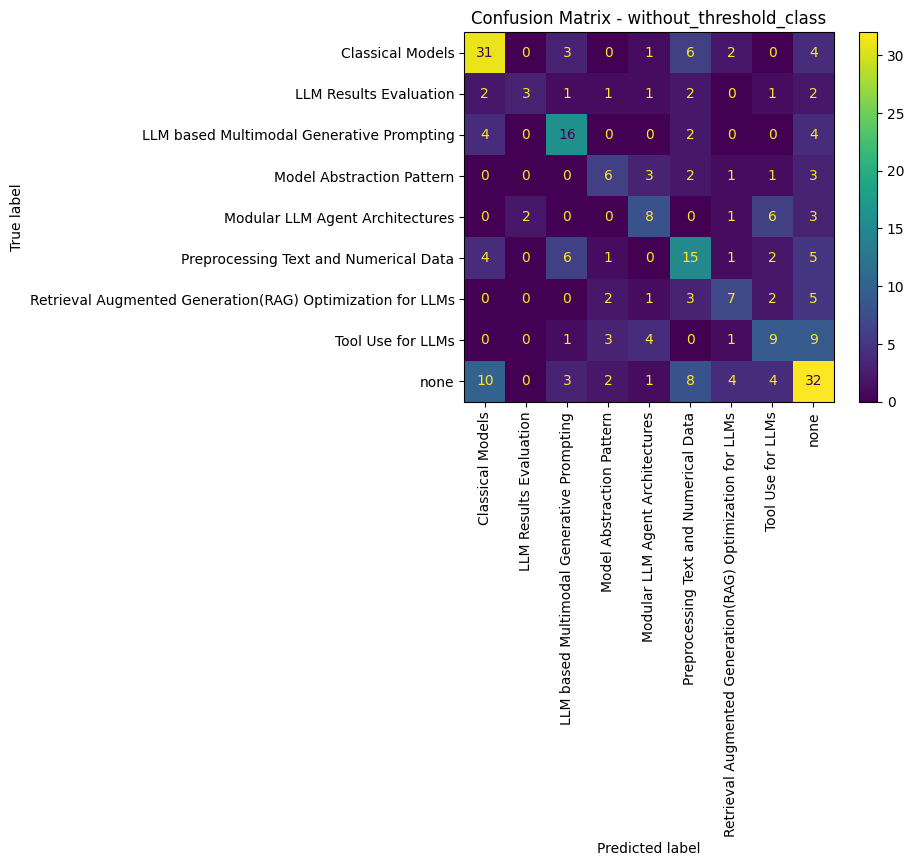


Classification Report for second_level_model_class_lr:
                                                           precision    recall  f1-score   support

                                         Classical Models       0.62      0.70      0.66        47
                                   LLM Results Evaluation       0.43      0.23      0.30        13
                LLM based Multimodal Generative Prompting       0.60      0.58      0.59        26
                                Model Abstraction Pattern       0.46      0.38      0.41        16
                          Modular LLM Agent Architectures       0.45      0.45      0.45        20
                    Preprocessing Text and Numerical Data       0.44      0.47      0.46        34
Retrieval Augmented Generation(RAG) Optimization for LLMs       0.52      0.55      0.54        20
                                        Tool Use for LLMs       0.48      0.37      0.42        27
                                                    

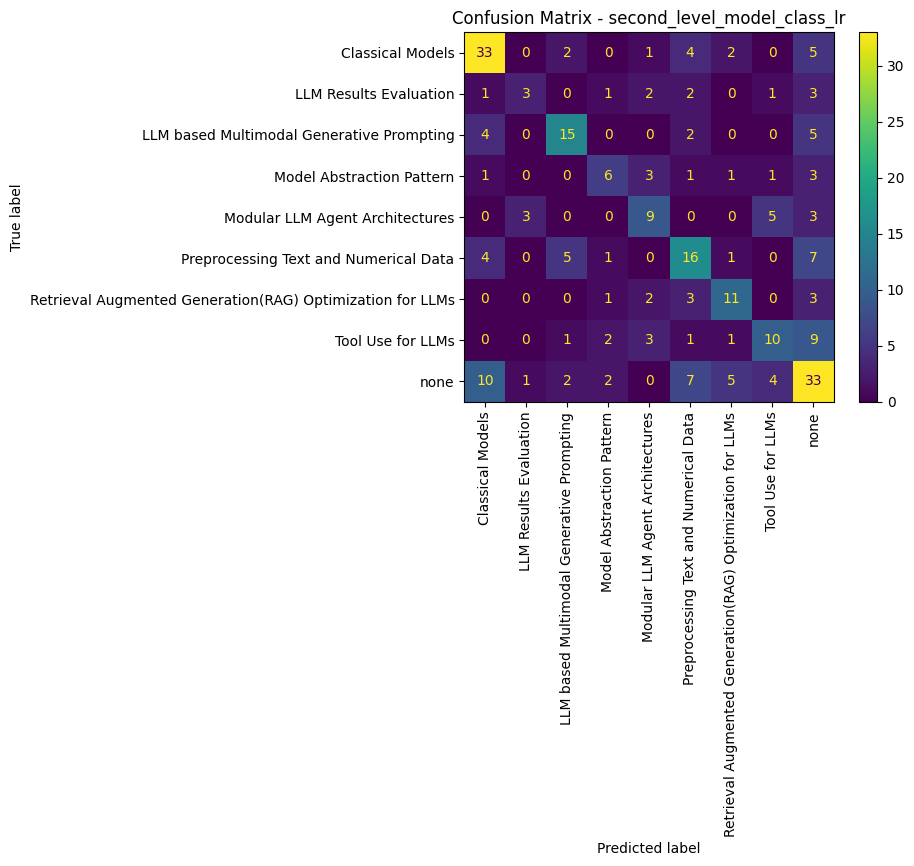


Classification Report for second_level_model_class_rr:
                                                           precision    recall  f1-score   support

                                         Classical Models       0.61      0.66      0.63        47
                                   LLM Results Evaluation       0.50      0.23      0.32        13
                LLM based Multimodal Generative Prompting       0.48      0.54      0.51        26
                                Model Abstraction Pattern       0.44      0.44      0.44        16
                          Modular LLM Agent Architectures       0.53      0.45      0.49        20
                    Preprocessing Text and Numerical Data       0.41      0.44      0.42        34
Retrieval Augmented Generation(RAG) Optimization for LLMs       0.56      0.50      0.53        20
                                        Tool Use for LLMs       0.42      0.37      0.39        27
                                                    

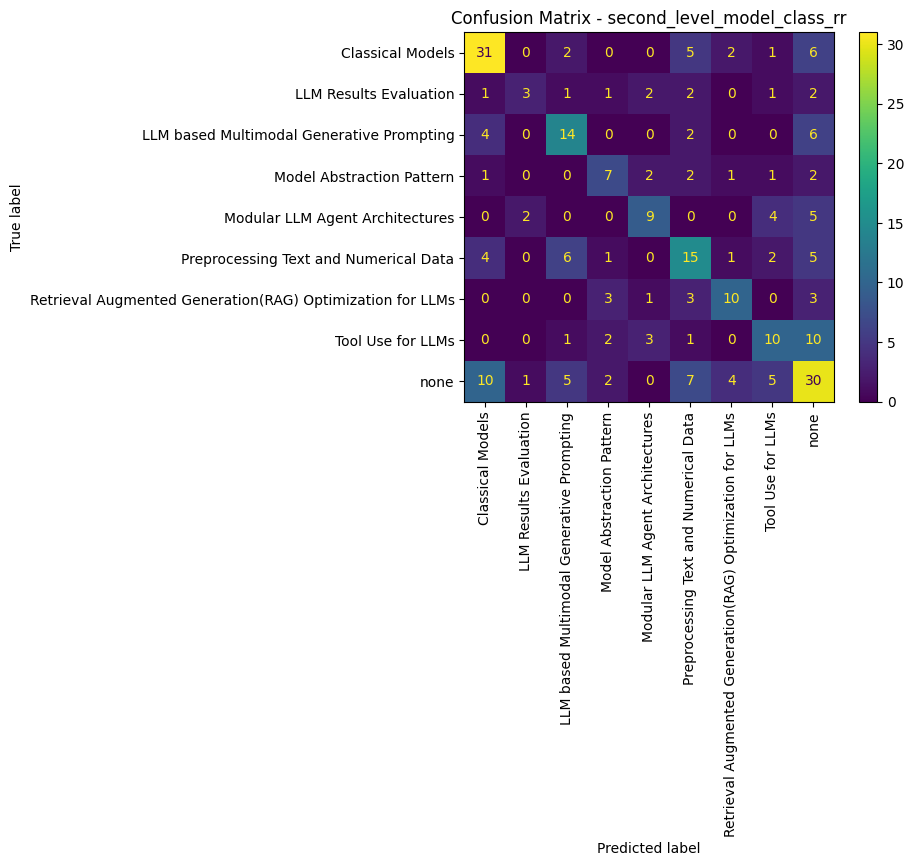

In [51]:
y_true = classification_results['verified_pattern']

print(f"With thresholding applied [precision]: {classification_report(y_true, classification_results['threshold_class'], output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")
print(f"Without thresholding [precision]: {classification_report(y_true, classification_results['without_threshold_class'], output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")
print(f"Second Level Model LR [precision]: {classification_report(y_true, classification_results['second_level_model_class_lr'], output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")
print(f"Second Level Model RR [precision]: {classification_report(y_true, classification_results['second_level_model_class_rr'], output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")

print()

print(f"With thresholding applied [f1]: {classification_report(y_true, classification_results['threshold_class'], output_dict=True, zero_division=0)['weighted avg']['f1-score']:.4f}")
print(f"Without thresholding [f1]: {classification_report(y_true, classification_results['without_threshold_class'], output_dict=True, zero_division=0)['weighted avg']['f1-score']:.4f}")
print(f"Second Level Model LR [f1]: {classification_report(y_true, classification_results['second_level_model_class_lr'], output_dict=True, zero_division=0)['weighted avg']['f1-score']:.4f}")
print(f"Second Level Model RR [f1]: {classification_report(y_true, classification_results['second_level_model_class_rr'], output_dict=True, zero_division=0)['weighted avg']['f1-score']:.4f}")


print(f"With thresholding applied [recall]: {classification_report(y_true, classification_results['threshold_class'], output_dict=True, zero_division=0)['weighted avg']['recall']:.4f}")
print(f"Without thresholding [recall]: {classification_report(y_true, classification_results['without_threshold_class'], output_dict=True, zero_division=0)['weighted avg']['recall']:.4f}")
print(f"Second Level Model LR [recall]: {classification_report(y_true, classification_results['second_level_model_class_lr'], output_dict=True, zero_division=0)['weighted avg']['recall']:.4f}")
print(f"Second Level Model RR [recall]: {classification_report(y_true, classification_results['second_level_model_class_rr'], output_dict=True, zero_division=0)['weighted avg']['recall']:.4f}")

for method in classification_results.columns:
    if 'class' in method:
        print(f"\nClassification Report for {method}:")
        print(classification_report(y_true, classification_results[method], zero_division=0))

        y_pred = classification_results[method]
        class_labels = np.unique(np.concatenate([y_true, y_pred]))


        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_labels
        )

        disp.plot()
        plt.xticks(rotation=90)
        plt.title(f"Confusion Matrix - {method}")
        plt.show()

### Predicted result ananlyze

In [4]:
import pandas as pd

In [5]:
forecast = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/predictions.csv")

forecast_dict = {}
for index, row in forecast.iterrows():
    forecast_dict[row['file']] = row['predicted_pattern']

In [25]:
forecast.head()

,predicted_pattern,file,Classical Models,LLM Results Evaluation,LLM based Multimodal Generative Prompting,Model Abstraction Pattern,Modular LLM Agent Architectures,Preprocessing Text and Numerical Data,Retrieval Augmented Generation(RAG) Optimization for LLMs,Tool Use for LLMs,none
0,LLM based Multimodal Generative Prompting,https://github.com/HasinthakaPiyumal/AI-Patter...,0.000883,0.033489,0.889751,0.001845,0.000742,0.000998,0.000507,0.000167,0.071616
1,none,https://github.com/HasinthakaPiyumal/AI-Patter...,0.000179,0.001528,0.000140,0.006830,0.000022,0.000826,0.003226,0.002850,0.984398
2,LLM based Multimodal Generative Prompting,https://github.com/HasinthakaPiyumal/AI-Patter...,0.000048,0.004628,0.995090,0.000016,0.000120,0.000021,0.000002,0.000001,0.000073
3,Preprocessing Text and Numerical Data,https://github.com/HasinthakaPiyumal/AI-Patter...,0.000137,0.000764,0.000083,0.000650,0.000079,0.939824,0.016692,0.000408,0.041363
4,none,https://github.com/HasinthakaPiyumal/AI-Patter...,0.000129,0.001506,0.000059,0.003589,0.000074,0.455710,0.044374,0.001084,0.493475


In [57]:
for j,i in forecast['predicted_pattern'].value_counts().items():
    print(j,'-', i)

none - 553
Classical Models - 275
Preprocessing Text and Numerical Data - 219
Tool Use for LLMs - 180
LLM based Multimodal Generative Prompting - 171
LLM Results Evaluation - 88
Retrieval Augmented Generation(RAG) Optimization for LLMs - 71
Modular LLM Agent Architectures - 70
Model Abstraction Pattern - 52


#### Combile forecast with descriptions

In [ ]:
labeld_data = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/labeled_data.csv')
labeld_data['predicted_pattern'] = labeld_data['file'].apply(lambda x: forecast_dict.get(x))

In [ ]:
labeld_data.to_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/labeled_data_with_predictions.csv", index=False)

In [41]:
summary_mapping = {file: summary for file, summary in zip(labeld_data['file'], labeld_data['code_summary'])}
verified_patterns = labeld_data.set_index('file')['verified_pattern'].to_dict()

In [13]:
eval_forecast = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768873823.3985023/l2_lr_ensemble_classification_predictions_with_probabilities.csv")
eval_forecast['code_summary'] = eval_forecast['file'].apply(lambda x: summary_mapping.get(x))

In [15]:
eval_forecast.to_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768873823.3985023/l2_lr_ensemble_classification_predictions_with_probabilities_and_summaries.csv", index=False)

### Selecting most uncertain communities 

In [6]:
pattern_cols = [
    "Classical Models",
    "LLM Results Evaluation",
    "LLM based Multimodal Generative Prompting",
    "Model Abstraction Pattern",
    "Modular LLM Agent Architectures",
    "Preprocessing Text and Numerical Data",
    "Retrieval Augmented Generation(RAG) Optimization for LLMs",
    "Tool Use for LLMs",
    "none"
]

In [ ]:
from collections import Counter

# collect misclassification pairs
confusion_pairs = [
    (row["verified_pattern"], row["second_level_model_class_lr"])
    for _, row in classification_results.iterrows()
    if row["verified_pattern"] != row["second_level_model_class_lr"]
]

pair_counts = Counter(confusion_pairs)
sorted_pairs = pair_counts.most_common()

confusion_rank_df = pd.DataFrame([{'rank':rank,'verified_pattern':pair[0],'predicted_pattern':pair[1],'count':count} for rank, (pair, count) in enumerate(sorted_pairs, 1)])
margin_list = []
for _,row in forecast.iterrows():
    scores = pd.to_numeric(row[pattern_cols], errors="coerce")
    top2 = scores.nlargest(3)

    top_1_class = top2.index[0]
    top_1_prob = top2.iloc[0]
    top_2_class = top2.index[1]
    top_2_prob = top2.iloc[1]

    #Filter only unverified patterns
    if str(verified_patterns.get(row['file']))!='nan':
        continue

    margin = (top_1_prob - top_2_prob)
    margin_list.append((_, top_1_class, top_2_class, margin,row['file']))

margin_list = sorted(margin_list, key=lambda x: x[3], reverse=True)

margin_df = pd.DataFrame(margin_list, columns=['index','top_class','second_top_class','margin','file'])  

merged_df = margin_df.merge(
    confusion_rank_df,
    left_on=["second_top_class", "top_class"],
    right_on=["verified_pattern", "predicted_pattern"],
    how="inner"
)
merged_df = merged_df.sort_values( 
    by=["margin","rank"],
    ascending=[True, True]
).reset_index(drop=True).iloc[:100]

In [ ]:
merged_df['code_summary'] = merged_df['file'].apply(lambda x: summary_mapping.get(x))
merged_df = merged_df.drop(columns=['index','verified_pattern','predicted_pattern','count'])
merged_df.to_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768873823.3985023/top_100_confusion_margin_ranked.csv", index=False)

In [59]:
merged_df

,top_class,second_top_class,margin,file,rank,code_summary
0,Preprocessing Text and Numerical Data,Classical Models,0.003239,https://github.com/HasinthakaPiyumal/AI-Patter...,13,This code implements a Conditional Tabular Gen...
1,none,Preprocessing Text and Numerical Data,0.005040,https://github.com/HasinthakaPiyumal/AI-Patter...,4,The code demonstrates diverse object detection...
2,Preprocessing Text and Numerical Data,none,0.006136,https://github.com/HasinthakaPiyumal/AI-Patter...,3,This code implements common image preprocessin...
3,none,Preprocessing Text and Numerical Data,0.006911,https://github.com/HasinthakaPiyumal/AI-Patter...,4,This code implements **vectorized HD map featu...
4,none,LLM Results Evaluation,0.009406,https://github.com/HasinthakaPiyumal/AI-Patter...,15,The code implements sophisticated multi-agent ...
...,...,...,...,...,...,...
95,Tool Use for LLMs,Model Abstraction Pattern,0.164335,https://github.com/HasinthakaPiyumal/AI-Patter...,41,This code implements multi-agent orchestration...
96,Preprocessing Text and Numerical Data,Classical Models,0.164686,https://github.com/HasinthakaPiyumal/AI-Patter...,13,This code implements a **Perceptual Loss** pat...
97,none,LLM based Multimodal Generative Prompting,0.165560,https://github.com/HasinthakaPiyumal/AI-Patter...,6,This code implements a robust **model export a...
98,none,Classical Models,0.167151,https://github.com/HasinthakaPiyumal/AI-Patter...,8,This code implements a specialized multi-head ...


In [52]:
uncertain_data = []
for (truth, prediction) in selected_pairs:
    for _,row in forecast.iterrows():
        scores = pd.to_numeric(row[pattern_cols], errors="coerce")
        top2 = scores.nlargest(3)

        top_1_class = top2.index[0]
        top_1_prob = top2.iloc[0]
        top_2_class = top2.index[1]
        top_2_prob = top2.iloc[1]
        top_3_class = top2.index[2]
        top_3_prob = top2.iloc[2]
        print(top_1_class, top_2_class, top_3_class)

        if top_1_class == prediction and (top_2_class == truth or top_3_class == prediction):
            uncertain_data.append((row['file'], (top_1_prob - top_2_prob)))

uncertain_data.sort(key=lambda x: x[1])

LLM based Multimodal Generative Prompting none LLM Results Evaluation
none Model Abstraction Pattern Retrieval Augmented Generation(RAG) Optimization for LLMs
LLM based Multimodal Generative Prompting LLM Results Evaluation Modular LLM Agent Architectures
Preprocessing Text and Numerical Data none Retrieval Augmented Generation(RAG) Optimization for LLMs
none Preprocessing Text and Numerical Data Retrieval Augmented Generation(RAG) Optimization for LLMs
none Model Abstraction Pattern Retrieval Augmented Generation(RAG) Optimization for LLMs
none Model Abstraction Pattern Retrieval Augmented Generation(RAG) Optimization for LLMs
none Preprocessing Text and Numerical Data Retrieval Augmented Generation(RAG) Optimization for LLMs
none Preprocessing Text and Numerical Data Retrieval Augmented Generation(RAG) Optimization for LLMs
LLM based Multimodal Generative Prompting LLM Results Evaluation none
LLM based Multimodal Generative Prompting LLM Results Evaluation none
none Model Abstraction

In [50]:
uncertain_data

[]

In [39]:

# -------------------------------
# STEP 1: Ensure numeric scores
# -------------------------------
forecast[pattern_cols] = forecast[pattern_cols].apply(
    pd.to_numeric, errors="coerce"
)

confusion_set = set(selected_pairs)

# -------------------------------
# STEP 3: Compute top-1, top-2
# -------------------------------
top2 = forecast[pattern_cols].apply(
    lambda r: r.nlargest(2),
    axis=1
)

forecast["top_1_class"] = top2.apply(lambda x: x.index[0])
forecast["top_1_prob"]  = top2.apply(lambda x: x.iloc[0])

forecast["top_2_class"] = top2.apply(lambda x: x.index[1])
forecast["top_2_prob"]  = top2.apply(lambda x: x.iloc[1])

forecast["prob_gap"] = forecast["top_1_prob"] - forecast["top_2_prob"]

# -------------------------------
# STEP 4: Filter by confusion logic
# -------------------------------
mask = forecast.apply(
    lambda r: (r["top_2_class"], r["top_1_class"]) in confusion_set,
    axis=1
)

# -------------------------------
# STEP 5: Final sorted output
# -------------------------------
data2label = list(
    zip(
        forecast.loc[mask, "file"],
        forecast.loc[mask, "prob_gap"]
    )
)

data2label.sort(key=lambda x: x[1])

In [40]:
data2label

[]